In [2]:
!pip install spacy-transformers
!python -m spacy download en_core_web_trf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.4/313.4 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled trans

In [3]:
import pandas as pd
import spacy
from collections import Counter
from tqdm import tqdm

## 3. Load Topic Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_parquet("/content/drive/MyDrive/NLP Final Project/topic_results_100_topics.parquet")

print(df.shape)

(146876, 11)


## 4. Load SpaCy Transformer Model

In [6]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 49.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [7]:
nlp = spacy.load("en_core_web_md")

## 5. Extract Entities Function

In [8]:
def extract_entities(text):

    doc = nlp(text)

    orgs = []
    tech = []
    locations = []

    for ent in doc.ents:

        if ent.label_ == "ORG":
            orgs.append(ent.text)

        elif ent.label_ == "PRODUCT":
            tech.append(ent.text)

        elif ent.label_ == "GPE":
            locations.append(ent.text)

    return orgs, tech, locations

## 6. Apply Entity Extraction

In [10]:
tqdm.pandas()

df[['orgs','technologies','locations']] = df['clean_text'].progress_apply(
    lambda x: pd.Series(extract_entities(x))
)

100%|██████████| 146876/146876 [3:24:12<00:00, 11.99it/s]


In [11]:
df.head(3)

,news_id,url,date,language,title,text,char_count,word_count,is_english,clean_text,topic,orgs,technologies,locations
0,0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","bad idea ai price (bad), , & chart history - b...",3501,483,True,bad idea ai price bad chart history blockworks...,16,"[campo researchsolana meta aggregatorsmeta, dexs]",[],"[spodcastseventsroundtablestoken, transparency..."
1,1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,this ai video of gymnastics might be the freak...,5585,812,True,ai video gymnastic freaky see boe boe blog pos...,-1,"[microsoft, microsoft, ipad pro half, apple ip...",[],"[milwaukee, milwaukee, china, yanarta, turkey]"
2,2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","if using ai feels like a chore, try this - boi...",5880,884,True,ai feel like chore try boe boe blog post forum...,-1,"[boe boe, boe boe, lenovo tinie dell micro, eb...",[],[]


## 7. Save Results

In [24]:
df.to_parquet("/content/drive/MyDrive/NLP Final Project/entity_results.parquet")

In [ ]:
import pandas as pd

company_freq = pd.read_csv("/content/drive/MyDrive/NLP Final Project/company_frequency.csv")
print(company_freq.head())

     Company  Mentions
0  microsoft    110206
1     amazon     36604
2        fcc     32667
3     google     29607
4    samsung     28636


## 8. Company Frequency Table

In [13]:
all_orgs = []

for org_list in df['orgs']:
    all_orgs.extend(org_list)

In [14]:
company_counts = Counter(all_orgs)

company_freq = pd.DataFrame(
    company_counts.items(),
    columns=['Company','Mentions']
)

company_freq = company_freq.sort_values(
    by='Mentions',
    ascending=False
)

company_freq.head(20)

,Company,Mentions
2,microsoft,83952
33,fcc,32561
242,samsung,25397
160,amazon,23151
525,ibm,16588
153,intel,14690
105,congress,13302
692,eu,12656
47,white house,11444
63,un,11176


## 9. Save Company Table

In [25]:
company_freq.to_csv("/content/drive/MyDrive/NLP Final Project/company_frequency.csv", index=False)

## 10. Technology Frequency Table

In [15]:
all_tech = []

for tech_list in df['technologies']:
    all_tech.extend(tech_list)

In [17]:
tech_counts = Counter(all_tech)

tech_freq = pd.DataFrame(
    tech_counts.items(),
    columns=['Technology','Mentions']
)

tech_freq = tech_freq.sort_values(
    by='Mentions',
    ascending=False
)

tech_freq.head(20)

,Technology,Mentions
8,gmt,2613
1,sep,1035
104,bmw,854
58,oneplus,659
53,discovery,593
151,apr edt,508
164,sep edt,432
52,cole,425
51,elon musk,414
30,english usa english,358


## 11. Save Technology Table

In [26]:
tech_freq.to_csv("/content/drive/MyDrive/NLP Final Project/technology_frequency.csv", index=False)

## 12. Basic Cleaning of Entities (Important)

In [19]:
company_freq = company_freq[
    company_freq['Company'].str.len() > 2
]

company_freq.head(20)

,Company,Mentions
2,microsoft,83952
33,fcc,32561
242,samsung,25397
160,amazon,23151
525,ibm,16588
153,intel,14690
105,congress,13302
47,white house,11444
1852,pbs,10960
529,fda,10606


In [20]:
tech_freq = tech_freq[
    tech_freq['Technology'].str.len() > 2
]

tech_freq.head(20)

,Technology,Mentions
8,gmt,2613
1,sep,1035
104,bmw,854
58,oneplus,659
53,discovery,593
151,apr edt,508
164,sep edt,432
52,cole,425
51,elon musk,414
30,english usa english,358


## 13. Plot Top Companies

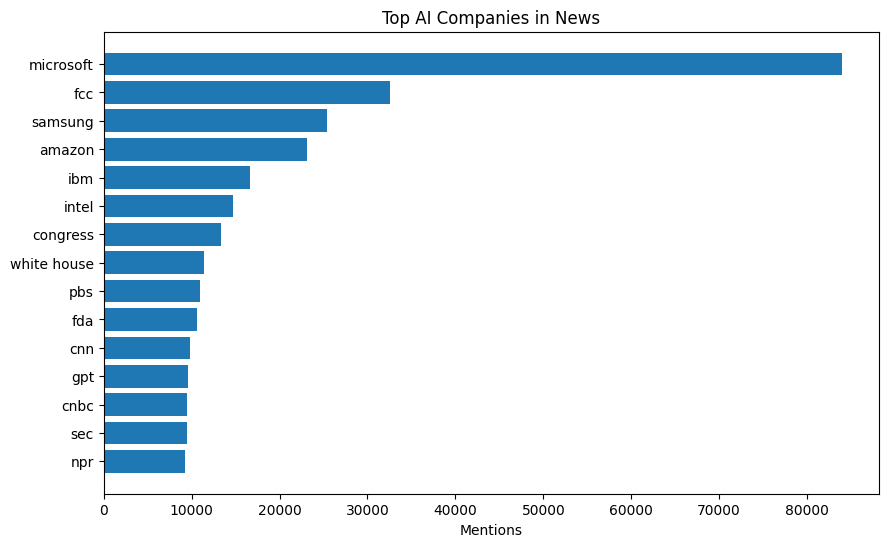

In [21]:
import matplotlib.pyplot as plt

top_companies = company_freq.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_companies['Company'],
    top_companies['Mentions']
)

plt.xlabel("Mentions")
plt.title("Top AI Companies in News")

plt.gca().invert_yaxis()

plt.show()

## 14. Plot Top Technologies

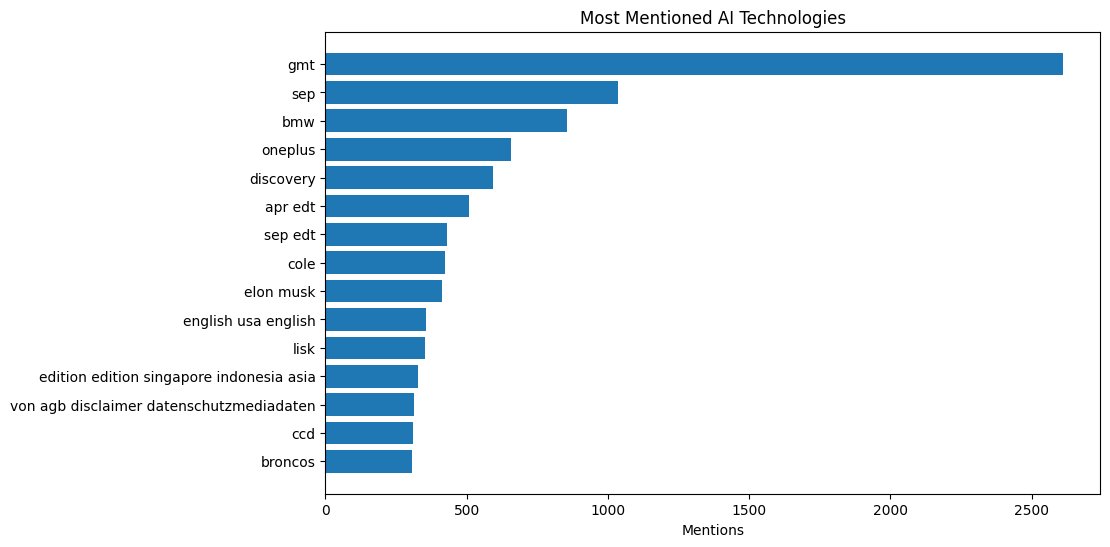

In [22]:
top_tech = tech_freq.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_tech['Technology'],
    top_tech['Mentions']
)

plt.xlabel("Mentions")
plt.title("Most Mentioned AI Technologies")

plt.gca().invert_yaxis()

plt.show()

## 15. Plot Top Location

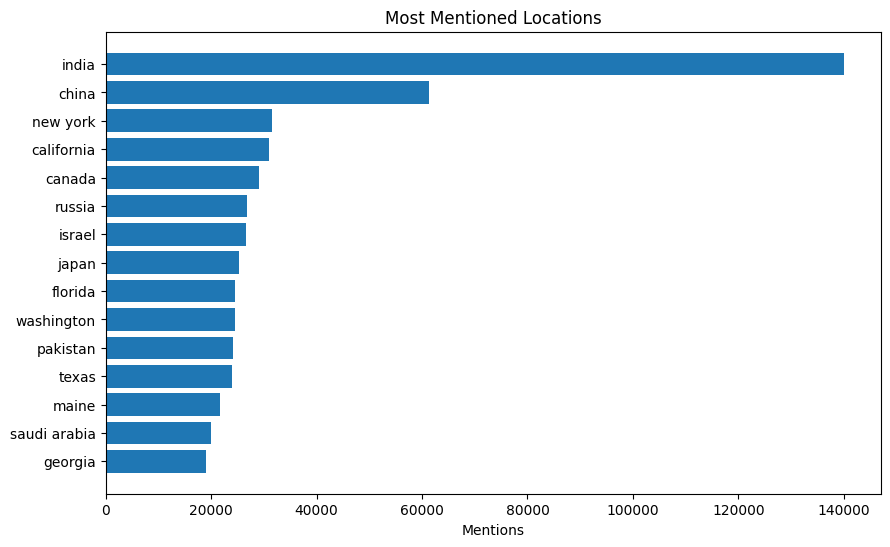

In [23]:
all_locations = []

for loc_list in df['locations']:
    all_locations.extend(loc_list)

location_counts = Counter(all_locations)

location_freq = pd.DataFrame(
    location_counts.items(),
    columns=['Location','Mentions']
)

location_freq = location_freq.sort_values(
    by='Mentions',
    ascending=False
)

location_freq = location_freq[
    location_freq['Location'].str.len() > 2
]

top_locations = location_freq.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_locations['Location'],
    top_locations['Mentions']
)

plt.xlabel("Mentions")
plt.title("Most Mentioned Locations")

plt.gca().invert_yaxis()

plt.show()